**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Clase 17 - Manejo de datos estructurados. Preprocesado, análisis y visualización**

## Complemento

Este notebook se complementa con la presentación: **schwabish-2014-an-economist-s-guide-to-visualizing-data.pdf**

Te recomendamos leer el PDF para trabajar con este notebook y tener una mejor comprensión de los conceptos teóricos.

## ¿Qué vamos a hacer en esta clase?

Vamos a trabajar con **dos datasets reales** siguiendo este pipeline:

| Parte | Dataset | Etapas |
|---|---|---|
| **A** | 🎵 Spotify Top Songs | Carga → Nulos y duplicados → Análisis → Visualización → Regresión |
| **B** | ⚽ Premier League 2023/24 | Carga → Preprocesado → Análisis → **Merge** → Visualización → Regresión |
| **C** | Ambos | Agente de análisis con lenguaje natural (Groq) |



In [1]:
import pandas as pd              
import numpy as np               
import matplotlib.pyplot as plt  
import seaborn as sns            

sns.set_theme(style="whitegrid", palette="muted")          # style = estilo de gráficos, palette = paleta de colores
pd.set_option("display.float_format", "{:,.2f}".format)   # display formato de números decimales

---
# 🎵 Parte A — Spotify Top Songs

## A1. Carga y exploración

El dataset contiene canciones de playlists de Spotify con variables de audio como energía, bailabilidad, tempo y popularidad.

### Documentación y descarga

| | |
|---|---|
| **Descarga directa** | [spotify_songs.csv](https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv) |
| **Documentación completa** | [TidyTuesday — Spotify Songs (2020-01-21)](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-01-21/readme.md) |
| **Fuente original** | Spotify Web API vía el paquete `spotifyr` de R |



In [2]:
url_spotify = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
df = pd.read_csv(url_spotify)    # cargar el CSV directamente desde internet
print("Dimensiones:", df.shape)  # ver cuántas filas y columnas tiene
df.head(3)                        # mostrar las primeras 3 filas

Dimensiones: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.63,1,0.06,0.10,0.00,0.07,0.52,122.04,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.97,1,0.04,0.07,0.00,0.36,0.69,99.97,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.43,0,0.07,0.08,0.00,0.11,0.61,124.01,176616


**Variables principales:**

| Variable | Descripción |
|---|---|
| `track_popularity` | Popularidad de 0 a 100 (calculada por Spotify según reproducciones recientes) |
| `playlist_genre` | Género de la playlist: `pop`, `rap`, `rock`, `latin`, `r&b`, `edm` |
| `danceability` | Qué tan apta es la canción para bailar (0–1) |
| `energy` | Intensidad y actividad percibida (0–1) |
| `valence` | Positividad musical: valores altos = alegre, bajos = triste (0–1) |
| `tempo` | Tempo estimado en BPM |
| `loudness` | Volumen promedio en decibeles (dB) |
| `duration_ms` | Duración de la canción en milisegundos |

### `[]` vs `()` en pandas

En Python hay dos símbolos que se usan todo el tiempo juntos y es importante no confundirlos:

| Símbolo | Nombre | Para qué sirve |
|---|---|---|
| `()` | Paréntesis | **Ejecutar** un método o función |
| `[]` | Corchetes | **Acceder** a algo dentro de una estructura |

---

**`()` — ejecutan algo**

Los paréntesis le dicen a Python *"corré esto ahora"*:

```python
df.isnull()        # ejecuta el método isnull → devuelve un DataFrame de True/False
df.sum()           # ejecuta el método sum → devuelve los totales por columna
df.head(3)         # ejecuta head pasándole 3 como argumento
```

Sin los `()`, no ejecutás nada — obtenés el objeto función sin correrlo.

---

**`[]` — acceden a algo**

Los corchetes seleccionan una parte de una estructura:

```python
df["energy"]                      # selecciona la columna "energy"
df[["energy", "tempo"]]          # selecciona esas dos columnas
df[df["popularidad"] > 50]       # filtra las filas donde popularidad > 50
```

---

**Juntos en una misma línea** (como en la celda siguiente):

```python
df.isnull().sum()[df.isnull().sum() > 0]
#         ↑↑             ↑↑
#     paréntesis      paréntesis   → ejecutan los métodos
#                ↑↑↑
#            corchetes             → filtran el resultado
```

**Regla simple: `()` hace algo, `[]` accede a algo.**

In [3]:
# Estadísticas descriptivas de las principales variables de audio
# describe() calcula: count, mean, std, min, 25%, 50%, 75%, max
df[["track_popularity", "danceability", "energy", "valence", "tempo"]].describe().round(2) #redondeo a dos decimales

,track_popularity,danceability,energy,valence,tempo
count,"32,833.00","32,833.00","32,833.00","32,833.00","32,833.00"
mean,42.48,0.65,0.70,0.51,120.88
std,24.98,0.15,0.18,0.23,26.90
min,0.00,0.00,0.00,0.00,0.00
25%,24.00,0.56,0.58,0.33,99.96
50%,45.00,0.67,0.72,0.51,121.98
75%,62.00,0.76,0.84,0.69,133.92
max,100.00,0.98,1.00,0.99,239.44


## A2. Preprocesado

El preprocesado tiene tres etapas: detectar **valores nulos**, eliminar **duplicados** y seleccionar las columnas útiles. En esta sección explicamos cada concepto antes de aplicarlo.

---

### ¿Qué es un NaN?

`NaN` significa *Not a Number* — es la forma que tiene pandas de decir **"acá no hay dato"**.

Es como una celda vacía en Excel. Puede aparecer porque:
- El dato nunca existió (ej: un artista sin nombre registrado en Spotify)
- Hubo un error en la carga del archivo
- Al hacer un `merge`, no había coincidencia entre las tablas

### ¿Por qué son peligrosos?

| Riesgo | ¿Qué pasa? |
|---|---|
| Operaciones matemáticas | `suma + NaN = NaN` — el resultado se contamina |
| Visualizaciones | Las filas con NaN se omiten sin aviso |
| Modelos de ML | La mayoría rechaza NaN y tira error al entrenar |

### ¿Cómo detectarlos?

```python
df.isnull().sum()           # cuenta nulos por columna
df.isnull().any(axis=1)    # marca las filas que tienen algún nulo
```

In [4]:
print("Nulos por columna:")
# df.isnull()       → crea un DataFrame de True/False: True donde hay NaN, False donde hay dato
# .sum()            → suma los True por columna (True=1, False=0) → conteo de nulos por columna
# [... > 0]         → filtra y muestra solo las columnas con al menos un nulo
print(df.isnull().sum()[df.isnull().sum() > 0])

# df.isnull().any(axis=1) → por cada FILA (axis=1), devuelve True si al menos UNA celda es NaN
# .sum()                  → cuenta cuántas filas en total tienen algún nulo
print(f"\nFilas con algún nulo: {df.isnull().any(axis=1).sum()}")

Nulos por columna:
track_name          5
track_artist        5
track_album_name    5
dtype: int64

Filas con algún nulo: 5


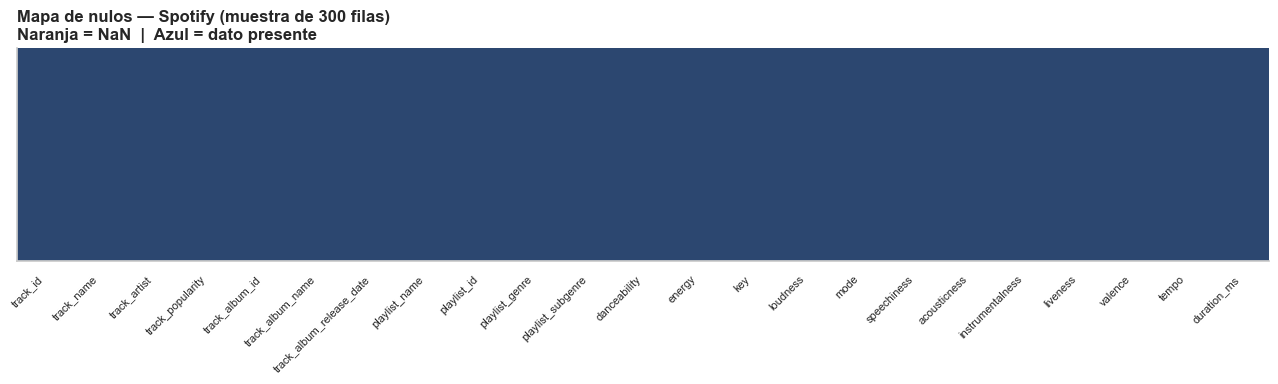

In [5]:
muestra = df.sample(300, random_state=42)   # 300 filas al azar para que el gráfico sea legible

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    muestra.isnull(),          # isnull() devuelve True donde hay NaN, False donde hay dato
    cbar=False,                # sin barra de color lateral
    cmap=["#2c4770", "#e07b39"],   # azul = dato presente | naranja = NaN
    yticklabels=False,         # ocultar etiquetas de filas (son números de índice, no aportan)
    ax=ax
)
ax.set_title("Mapa de nulos — Spotify (muestra de 300 filas)\nNaranja = NaN  |  Azul = dato presente",
             loc="left", fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
sns.despine()
plt.tight_layout()
plt.show()

In [6]:
# Tres formas de tratar los nulos — elegimos según la situación

# Opción A — dropna(): eliminar las filas que tienen algún nulo
df_A = df.dropna()
print(f"dropna():        {len(df):,} → {len(df_A):,} filas  (se pierden {len(df)-len(df_A)} filas)")

# Opción B — fillna(texto): rellenar con un valor fijo
df_B = df.fillna("Desconocido")   # reemplaza NaN con el texto "Desconocido"
print(f"fillna(texto):   nulos restantes = {df_B.isnull().sum().sum()}")

# Opción C — fillna(mediana): para columnas numéricas, rellenar con la mediana
df_C = df.fillna(df.median(numeric_only=True))   # median() calcula la mediana de cada columna numérica
print(f"fillna(mediana): nulos numéricos restantes = {df_C.select_dtypes('number').isnull().sum().sum()}")

# En este dataset son solo 5 filas de 32.833 → cualquiera de las tres opciones es válida

dropna():        32,833 → 32,828 filas  (se pierden 5 filas)
fillna(texto):   nulos restantes = 0
fillna(mediana): nulos numéricos restantes = 0


---

### ¿Qué son los duplicados?

Son filas que aparecen más de una vez en el dataset con los mismos valores.

**Analogía:** es como tener el mismo alumno anotado dos veces en el listado de clase. Si calculás el promedio o la suma, el resultado queda mal porque estás contando esa persona dos veces.

### ¿Por qué aparecen en Spotify?

La misma canción puede estar en varias playlists. En el CSV original:
- **32.833 filas** en total
- **28.356 canciones únicas** (identificadas por `track_id`)
- **4.477 filas duplicadas** — misma canción, distinta playlist

Si no se eliminan, estadísticas como la popularidad promedio quedan **sesgadas** hacia las canciones que aparecen en más playlists.

### Cómo detectarlos y eliminarlos

```python
# Detectar
df.duplicated(subset="columna_id").sum()

# Eliminar — keep="first" conserva la primera aparición
df.drop_duplicates(subset="columna_id", keep="first").reset_index(drop=True)
```

### ¿Qué poner en `subset`?

`subset` define **qué columnas usás para decidir si dos filas son iguales**. Depende de lo que signifique "duplicado" en tu dataset.

La pregunta clave es: *¿qué hace que dos filas sean "el mismo registro"?*

| Dataset | `subset` correcto | ¿Por qué? |
|---|---|---|
| Spotify | `"track_id"` | Cada canción tiene un ID único — si se repite el ID, es la misma canción |
| Alumnos | `"dni"` | Cada persona tiene un DNI único |
| Ventas | `["cliente", "fecha", "producto"]` | Una venta es única por esa combinación |
| Tabla sin ID | *(sin subset)* | No hay columna identificadora — una fila idéntica en todo es un duplicado |

La clave es entender el **dominio del problema**, no seguir una regla fija.

In [7]:
# Eliminar duplicados — misma canción en varias playlists
# subset="track_id": dos filas son "duplicadas" si tienen el mismo track_id
# reset_index(drop=True): reordena el índice de 0 a N-1 después de eliminar filas
sp_unique = df.drop_duplicates(subset="track_id").reset_index(drop=True)
print(f"Filas originales: {len(df):,}")
print(f"Sin duplicados:   {len(sp_unique):,}")  # 4.477 canciones estaban repetidas en varias playlists

Filas originales: 32,833
Sin duplicados:   28,356


In [8]:
# Columnas que vamos a usar (descartamos IDs, álbumes, cuotas de apuestas, etc.)
cols = ["track_name", "track_artist", "track_popularity",
        "playlist_genre", "danceability", "energy",
        "valence", "tempo", "loudness", "duration_ms"]
sp = sp_unique[cols].copy()   # crear un DataFrame nuevo solo con esas columnas

# Renombrar columnas para que los nombres sean más claros
sp = sp.rename(columns={
    "playlist_genre":   "genero",
    "track_popularity": "popularidad",
    "track_artist":     "artista",
    "track_name":       "cancion"
})

# Convertir duración de milisegundos a minutos (más fácil de interpretar)
sp["duracion_min"] = (sp["duration_ms"] / 60_000).round(2)
sp = sp.drop(columns="duration_ms")   # eliminar la columna original en ms
sp.head()

,cancion,artista,popularidad,genero,danceability,energy,valence,tempo,loudness,duracion_min
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,pop,0.75,0.92,0.52,122.04,-2.63,3.25
1,Memories - Dillon Francis Remix,Maroon 5,67,pop,0.73,0.81,0.69,99.97,-4.97,2.71
2,All the Time - Don Diablo Remix,Zara Larsson,70,pop,0.68,0.93,0.61,124.01,-3.43,2.94
3,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,pop,0.72,0.93,0.28,121.96,-3.78,2.82
4,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,pop,0.65,0.83,0.72,123.98,-4.67,3.15


---

## A3. Análisis

In [9]:
# Popularidad promedio por género
# groupby("genero"): agrupa las canciones por género
# ["popularidad"].mean(): calcula el promedio de popularidad en cada grupo
# sort_values(ascending=False): ordena de mayor a menor
pop_genero = sp.groupby("genero")["popularidad"].mean().sort_values(ascending=False).round(1)
pop_genero

genero
pop     45.90
rap     41.80
latin   41.40
rock    39.70
r&b     35.90
edm     30.70
Name: popularidad, dtype: float64

In [10]:
# Top 10 canciones más populares
# nlargest(10, "popularidad"): selecciona las 10 filas con mayor valor en "popularidad"
sp.nlargest(10, "popularidad")[["cancion", "artista", "genero", "popularidad"]]

,cancion,artista,genero,popularidad
1504,Dance Monkey,Tones and I,pop,100
18031,ROXANNE,Arizona Zervas,latin,99
687,Tusa,KAROL G,pop,98
711,Memories,Maroon 5,pop,98
716,Blinding Lights,The Weeknd,pop,98
1299,Circles,Post Malone,pop,98
5133,The Box,Roddy Ricch,rap,98
689,everything i wanted,Billie Eilish,pop,97
1300,Don't Start Now,Dua Lipa,pop,97
2941,Falling,Trevor Daniel,pop,97


---

## A4. Visualización con Seaborn

> **Principios de Schwabish aplicados:**
> - Grillas tenues (`whitegrid`) en lugar de grillas pesadas
> - Sin bordes superiores ni derechos (`despine`)
> - Paletas de color semánticas, no decorativas

### Matplotlib vs Seaborn — ¿cuándo usar cada uno?

Ambas librerías sirven para hacer gráficos en Python, pero operan a distinto nivel:

| | **Matplotlib** | **Seaborn** |
|---|---|---|
| **Nivel** | Bajo — controlás cada detalle | Alto — con una línea tenés un gráfico completo |
| **Código** | Más verboso | Muy conciso |
| **Integración con pandas** | Manual | Directa — acepta DataFrames |
| **Estética por defecto** | Básica | Prolija y lista para publicar |
| **Flexibilidad** | Total — podés hacer cualquier cosa | Limitada a los tipos de gráfico que incluye |

---

**Matplotlib** — control total, más código

```python
fig, ax = plt.subplots()
ax.bar(["pop", "rap", "rock"], [45.9, 41.8, 39.7], color="steelblue")
ax.set_title("Popularidad por género")
ax.set_ylabel("Popularidad promedio")
plt.show()
```

**Seaborn** — mismo resultado, menos código

```python
sns.barplot(data=sp, x="genero", y="popularidad")
plt.show()
```

---

**¿Cuándo usar cada uno?**

- **Seaborn** → para exploración y análisis: boxplots, barplots, histogramas, scatterplots. Es la primera opción.
- **Matplotlib** → cuando necesitás algo que seaborn no tiene: combinar gráficos, ajustar posiciones exactas, exportar en formatos especiales.

> En la práctica se usan juntos: seaborn hace el gráfico y matplotlib ajusta los detalles (`ax.set_title`, `plt.tight_layout`, etc.).

C:\Users\juanc\AppData\Local\Temp\ipykernel_20044\1348043338.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


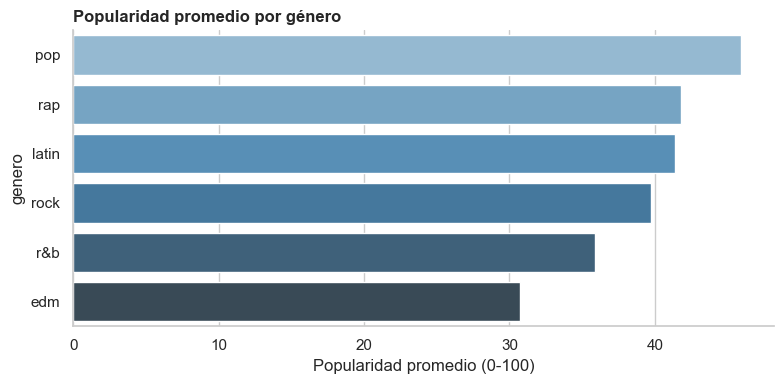

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    x=pop_genero.values,   # valores numéricos de popularidad promedio
    y=pop_genero.index,    # nombres de los géneros
    palette="Blues_d",
    ax=ax
)
ax.set_title("Popularidad promedio por género", loc="left", fontweight="bold")
ax.set_xlabel("Popularidad promedio (0-100)")
sns.despine()
plt.tight_layout()
plt.show()

---

## A5. Regresión lineal simple

¿Pueden las características de audio predecir la popularidad de una canción?

Usamos `energy` como predictor y `popularidad` como variable a explicar:

$$\text{popularidad} = \beta_0 + \beta_1 \cdot \text{energy} + \varepsilon$$

In [13]:
from sklearn.linear_model import LinearRegression

X = sp[["energy"]].values    # variable predictora — debe ser un array 2D (columna)
y = sp["popularidad"].values  # variable a predecir — array 1D

modelo = LinearRegression().fit(X, y)   # ajustar el modelo a los datos

print(f"β₀ = {modelo.intercept_:.2f}   (intercepto — valor de popularidad cuando energy = 0)")
print(f"β₁ = {modelo.coef_[0]:.2f}   (por cada +1 de energy, la popularidad cambia en β₁)")
print(f"R² = {modelo.score(X, y):.3f}  (proporción de varianza explicada; 0 = nada, 1 = todo)")

β₀ = 48.68   (intercepto — valor de popularidad cuando energy = 0)
β₁ = -13.38   (por cada +1 de energy, la popularidad cambia en β₁)
R² = 0.011  (proporción de varianza explicada; 0 = nada, 1 = todo)


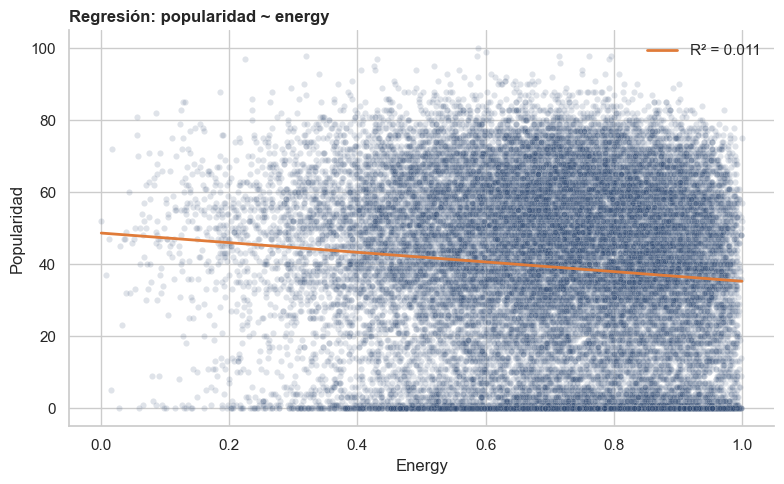

In [14]:
import numpy as np

# 100 puntos equidistantes entre el mínimo y máximo de energy, para dibujar la línea
x_rango = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=sp["energy"], y=sp["popularidad"],
                alpha=0.15, color="#2c4770", s=20, ax=ax)   # nube de puntos semitransparente
ax.plot(x_rango, modelo.predict(x_rango),                   # línea de regresión ajustada
        color="#e07b39", linewidth=2,
        label=f"R² = {modelo.score(X, y):.3f}")
ax.set_title("Regresión: popularidad ~ energy", loc="left", fontweight="bold")
ax.set_xlabel("Energy")
ax.set_ylabel("Popularidad")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

---
# ⚽ Parte B — Premier League 2023/24

## B1. Carga y exploración

El dataset contiene todos los partidos de la Premier League 2023/24 con goles, tiros, tarjetas y más.

### Documentación y descarga

| | |
|---|---|
| **Descarga directa** | [E0.csv — Premier League 2023/24](https://www.football-data.co.uk/mmz4281/2324/E0.csv) |
| **Documentación completa** | [football-data.co.uk — Notas de columnas](https://www.football-data.co.uk/notes.txt) |
| **Fuente** | [football-data.co.uk](https://www.football-data.co.uk/) — datos históricos de ligas europeas |

**Variables principales (post-renombre):**

| Variable original | Variable renombrada | Descripción |
|---|---|---|
| `HomeTeam` / `AwayTeam` | `local` / `visitante` | Equipos del partido |
| `FTHG` / `FTAG` | `goles_local` / `goles_visitante` | Goles al final del partido (Full Time) |
| `FTR` | `resultado` | Resultado: `H` (local), `A` (visitante), `D` (empate) |
| `HS` / `AS` | `tiros_local` / `tiros_visitante` | Total de tiros |
| `HST` / `AST` | `al_arco_local` / `al_arco_visitante` | Tiros al arco |
| `HY` / `AY` | `amarillas_local` / `amarillas_visitante` | Tarjetas amarillas |
| `HR` / `AR` | `rojas_local` / `rojas_visitante` | Tarjetas rojas |

> El dataset original tiene 106 columnas — la mayoría son cuotas de apuestas de distintas casas.

In [15]:
url_pl = "https://www.football-data.co.uk/mmz4281/2324/E0.csv"
pl = pd.read_csv(url_pl)     # cargar CSV de la Premier League desde internet
print("Dimensiones:", pl.shape)  # 380 partidos x 106 columnas (mayoría son cuotas de apuestas)
pl.head(3)

Dimensiones: (380, 106)


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,11/08/2023,20:00,Burnley,Man City,0,3,A,0,2,...,2.28,1.50,1.95,1.98,1.95,1.97,NaN,NaN,1.92,1.95
1,E0,12/08/2023,12:30,Arsenal,Nott'm Forest,2,1,H,2,0,...,2.63,-2.00,1.95,1.98,1.93,1.97,2.01,2.09,1.95,1.92
2,E0,12/08/2023,15:00,Bournemouth,West Ham,1,1,D,0,0,...,2.12,0.00,2.02,1.91,2.01,1.92,2.06,1.96,1.96,1.91


---

## B2. Preprocesado

In [16]:
# Columnas que nos interesan (descartamos las 90+ columnas de cuotas de apuestas)
cols_pl = ["Date", "HomeTeam", "AwayTeam",
           "FTHG", "FTAG", "FTR",
           "HS", "AS", "HST", "AST",
           "HY", "AY", "HR", "AR"]
pl = pl[cols_pl].copy()   # nuevo DataFrame solo con esas columnas

# Renombrar para que los nombres sean más claros
pl = pl.rename(columns={
    "HomeTeam": "local",           "AwayTeam": "visitante",
    "FTHG": "goles_local",         "FTAG": "goles_visitante",    "FTR": "resultado",
    "HS":   "tiros_local",         "AS":   "tiros_visitante",
    "HST":  "al_arco_local",       "AST":  "al_arco_visitante",
    "HY":   "amarillas_local",     "AY":   "amarillas_visitante",
    "HR":   "rojas_local",         "AR":   "rojas_visitante"
})

pl["Date"] = pd.to_datetime(pl["Date"], dayfirst=True)           # convertir texto a fecha
pl["goles_total"] = pl["goles_local"] + pl["goles_visitante"]    # nueva columna: goles del partido
pl.head()

,Date,local,visitante,goles_local,goles_visitante,resultado,tiros_local,tiros_visitante,al_arco_local,al_arco_visitante,amarillas_local,amarillas_visitante,rojas_local,rojas_visitante,goles_total
0,2023-08-11,Burnley,Man City,0,3,A,6,17,1,8,0,0,1,0,3
1,2023-08-12,Arsenal,Nott'm Forest,2,1,H,15,6,7,2,2,2,0,0,3
2,2023-08-12,Bournemouth,West Ham,1,1,D,14,16,5,3,1,4,0,0,2
3,2023-08-12,Brighton,Luton,4,1,H,27,9,12,3,2,2,0,0,5
4,2023-08-12,Everton,Fulham,0,1,A,19,9,9,2,0,2,0,0,1


In [17]:
print("Nulos por columna:")
print(pl.isnull().sum()[pl.isnull().sum() > 0])   # mostrar solo columnas con algún nulo
print("(Si no aparece nada, el dataset no tiene nulos)")

Nulos por columna:
Series([], dtype: int64)
(Si no aparece nada, el dataset no tiene nulos)


---

## B3. Análisis — Tabla de posiciones

In [18]:
# Construir la tabla de posiciones a partir de los resultados partido a partido

# pl[["local", "visitante"]]  -> DataFrame de 2 columnas con los nombres de equipos
# .values                     -> lo convierte a un array 2D de numpy (380 filas x 2 columnas)
# .ravel()                    -> aplana ese array 2D a 1D (760 valores en una sola lista)
#                               necesario porque pd.unique espera una lista, no una matriz
# pd.unique(...)              -> elimina los repetidos -> queda la lista de los 20 equipos unicos
equipos = pd.unique(pl[["local", "visitante"]].values.ravel())

# lista vacia donde vamos a guardar un diccionario por cada equipo
# al final del loop tendra 20 diccionarios -> pd.DataFrame los convierte en 20 filas
tabla = []

# recorremos los 20 equipos uno por uno
for equipo in equipos:

    # filtramos las filas donde este equipo jugo de local (19 partidos)
    # pl["local"] == equipo genera una serie de True/False; pl[...] se queda con las filas True
    como_local     = pl[pl["local"]     == equipo]

    # mismo filtro pero para cuando jugo de visitante (otros 19 partidos)
    como_visitante = pl[pl["visitante"] == equipo]

    # partidos jugados: 19 de local + 19 de visitante = 38
    pj  = len(como_local) + len(como_visitante)

    # victorias: "H" (Home) cuando es local + "A" (Away) cuando es visitante
    # .sum() cuenta cuantos True hay en cada condicion
    pg  = (como_local["resultado"] == "H").sum() + (como_visitante["resultado"] == "A").sum()

    # empates: "D" (Draw) tanto de local como de visitante
    pe  = (como_local["resultado"] == "D").sum() + (como_visitante["resultado"] == "D").sum()

    # derrotas: los partidos que no fueron victoria ni empate
    pp  = pj - pg - pe

    # goles a favor: los que metio como local + los que metio como visitante
    gf  = como_local["goles_local"].sum() + como_visitante["goles_visitante"].sum()

    # goles en contra: los que le metieron como local + los que le metieron como visitante
    gc  = como_local["goles_visitante"].sum() + como_visitante["goles_local"].sum()

    # puntos: victoria = 3 pts, empate = 1 pt, derrota = 0 pts
    pts = pg * 3 + pe

    # agregamos un diccionario con las estadisticas del equipo a la lista
    # cada clave del diccionario sera una columna del DataFrame final
    tabla.append({"Equipo": equipo, "PJ": pj, "PG": pg, "PE": pe,
                  "PP": pp, "GF": gf, "GC": gc, "DG": gf - gc, "Pts": pts})

# convertimos la lista de 20 diccionarios en un DataFrame
# sort_values: ordena por puntos de mayor a menor
# reset_index + index += 1: el indice arranca en 1 (posicion 1, 2, 3...)
tabla_pos = pd.DataFrame(tabla).sort_values("Pts", ascending=False).reset_index(drop=True)
tabla_pos.index += 1
tabla_pos

,Equipo,PJ,PG,PE,PP,GF,GC,DG,Pts
1,Man City,38,28,7,3,96,34,62,91
2,Arsenal,38,28,5,5,91,29,62,89
3,Liverpool,38,24,10,4,86,41,45,82
4,Aston Villa,38,20,8,10,76,61,15,68
5,Tottenham,38,20,6,12,74,61,13,66
6,Chelsea,38,18,9,11,77,63,14,63
7,Newcastle,38,18,6,14,85,62,23,60
8,Man United,38,18,6,14,57,58,-1,60
9,West Ham,38,14,10,14,60,74,-14,52
10,Crystal Palace,38,13,10,15,57,58,-1,49


In [19]:
# Promedio de goles por partido
print("Goles promedio por partido:", pl["goles_total"].mean().round(2))

# Partido con más goles — idxmax() devuelve el índice de la fila con el valor máximo
print("\nPartido con más goles:")
print(pl.loc[pl["goles_total"].idxmax(), ["local", "visitante", "goles_local", "goles_visitante"]])

Goles promedio por partido: 3.28

Partido con más goles:
local              Sheffield United
visitante                 Newcastle
goles_local                       0
goles_visitante                   8
Name: 58, dtype: object


---

## B4. Merge — Unir tablas

### ¿Qué es un merge?

Un merge es como juntar dos planillas de Excel por una **columna en común**.

**Analogía:** tenés dos planillas sobre los equipos de la Premier League:
- **Tabla A** — posiciones: equipo, puntos, goles a favor, goles en contra
- **Tabla B** — estadios: equipo, ciudad, capacidad del estadio

Ambas tienen la columna `"Equipo"`. El merge une las dos planillas para que cada equipo quede con sus puntos **y** su estadio en la misma fila.

```python
tabla_A.merge(tabla_B, on="Equipo", how="left")
```

### Parámetros clave

| Parámetro | ¿Qué controla? |
|---|---|
| `on="columna"` | La columna en común por la que se unen las tablas |
| `how="inner"` | Solo las filas que están **en ambas** tablas |
| `how="left"` | **Todas** las filas de la tabla izquierda; lo que no matchea queda con NaN |
| `how="right"` | **Todas** las filas de la tabla derecha |
| `how="outer"` | **Todas** las filas de ambas tablas; lo que no matchea queda con NaN |

In [20]:
# Tabla A: posiciones completas (20 equipos, construida en B3)
tabla_A = tabla_pos[["Equipo", "Pts", "GF", "GC"]].copy()

# Tabla B: información de estadios — solo 15 de los 20 equipos
# Dejamos 5 fuera adrede para ilustrar cómo se comporta cada tipo de join
tabla_B = pd.DataFrame({
    "Equipo": ["Man City", "Arsenal", "Liverpool", "Chelsea", "Tottenham",
               "Newcastle", "Man United", "Aston Villa", "West Ham", "Brighton",
               "Wolves", "Fulham", "Everton", "Brentford", "Bournemouth"],
    "Ciudad": ["Manchester", "Londres", "Liverpool", "Londres", "Londres",
               "Newcastle", "Manchester", "Birmingham", "Londres", "Brighton",
               "Wolverhampton", "Londres", "Liverpool", "Londres", "Bournemouth"],
    "Capacidad_Estadio": [53400, 60704, 53394, 40341, 62850,
                          52305, 74310, 42785, 62500, 31876,
                          31700, 25700, 39572, 17250, 11307]
})

print(f"Tabla A — {len(tabla_A)} equipos (posiciones):")
display(tabla_A.head(3))

print(f"\nTabla B — {len(tabla_B)} equipos (estadios, faltan 5):")
display(tabla_B.head(3))

# Los 5 equipos que tienen posición pero no tienen estadio en Tabla B
faltantes = set(tabla_A["Equipo"]) - set(tabla_B["Equipo"])
print(f"\nEquipos en A pero NO en B: {faltantes}")

Tabla A — 20 equipos (posiciones):


,Equipo,Pts,GF,GC
1,Man City,91,96,34
2,Arsenal,89,91,29
3,Liverpool,82,86,41



Tabla B — 15 equipos (estadios, faltan 5):


,Equipo,Ciudad,Capacidad_Estadio
0,Man City,Manchester,53400
1,Arsenal,Londres,60704
2,Liverpool,Liverpool,53394



Equipos en A pero NO en B: {"Nott'm Forest", 'Luton', 'Burnley', 'Sheffield United', 'Crystal Palace'}


### Los 4 tipos de join

Cada tipo controla **qué filas** se conservan en el resultado:

<img src="https://miro.medium.com/v2/resize:fit:1200/1*9eH1_7VbTZPZd9jBiGIyNA.png" width="500"/>

| Tipo | Filas conservadas | En nuestro ejemplo |
|---|---|---|
| `inner` | Solo las que matchean en **ambas** tablas | 15 equipos (los 5 sin estadio se pierden) |
| `left` | **Todas** de A + lo que haya en B | 20 equipos; los 5 sin estadio quedan con NaN |
| `right` | **Todas** de B + lo que haya en A | 15 equipos de B |
| `outer` | **Todas** de A y de B | 20 equipos; NaN donde no hay coincidencia |

### ¿Qué join usar?

El **left join** es el más común en la práctica:

> *"Tengo mi tabla principal y quiero enriquecerla con columnas de otra tabla. Me quedo con todos mis datos y agrego lo que encuentre."*

| Join | Cuándo usarlo |
|---|---|
| **inner** | Querés solo registros que existen en **ambas** tablas; aceptás perder los que no matchean |
| **left** | Tu tabla base es la izquierda y no querés perder ningún registro de ella |
| **right** | Igual que left pero tu tabla base es la derecha |
| **outer** | Querés **todos** los registros de ambas tablas, aunque generen NaN |

⚠️ **Regla de oro:** después de cualquier merge, verificá siempre:
1. ¿La cantidad de filas es la esperada?
2. ¿Aparecieron NaN nuevos?
3. ¿Hay filas duplicadas inesperadas?

```python
print(f"Filas antes del merge: {len(tabla_A)}")
print(f"Filas después:         {len(resultado)}")
print(resultado.isnull().sum())
```

In [21]:
# ── INNER: solo los equipos que están en AMBAS tablas ────────────────────────
inner = tabla_A.merge(tabla_B, on="Equipo", how="inner")
print(f"INNER: {len(inner)} filas  (se pierden los 5 equipos sin estadio)")

# ── LEFT: todos de A + lo que haya en B; donde no hay match → NaN ────────────
left = tabla_A.merge(tabla_B, on="Equipo", how="left")
print(f"LEFT:  {len(left)} filas  (los 5 sin estadio quedan con NaN)")
display(left[left["Ciudad"].isnull()])   # ver cuáles son

# ── OUTER: todos de A y de B ─────────────────────────────────────────────────
outer = tabla_A.merge(tabla_B, on="Equipo", how="outer")
print(f"OUTER: {len(outer)} filas")

INNER: 15 filas  (se pierden los 5 equipos sin estadio)
LEFT:  20 filas  (los 5 sin estadio quedan con NaN)


,Equipo,Pts,GF,GC,Ciudad,Capacidad_Estadio
9,Crystal Palace,49,57,58,NaN,NaN
16,Nott'm Forest,36,49,67,NaN,NaN
17,Luton,26,52,85,NaN,NaN
18,Burnley,24,41,78,NaN,NaN
19,Sheffield United,16,35,104,NaN,NaN


OUTER: 20 filas


---

## Resumen — Pipeline de preprocesado

Estas tres operaciones forman el núcleo del preprocesado antes de cualquier análisis o modelo:

| Paso | Función | Qué hace |
|---|---|---|
| **1. Nulos — detectar** | `isnull().sum()` | Cuenta cuántos NaN hay por columna |
| **1. Nulos — visualizar** | `sns.heatmap(df.isnull())` | Muestra el patrón de datos faltantes |
| **1. Nulos — tratar** | `dropna()` / `fillna()` | Elimina o imputa los valores faltantes |
| **2. Duplicados** | `drop_duplicates(subset="id")` | Elimina filas repetidas |
| **3. Merge** | `df_a.merge(df_b, on="col", how="left")` | Une dos tablas por una columna en común |

**Pipeline típico:**

```python
df = pd.read_csv("archivo.csv")           # 1. Cargar

print(df.shape)                            # 2. Inspeccionar
df.isnull().sum()

df = df.dropna()                           # 3. Nulos
df = df.drop_duplicates(subset="id")      # 4. Duplicados
    .reset_index(drop=True)

df = df.merge(df_extra, on="id",          # 5. Merge (si necesitás enriquecer)
              how="left")

print(df.shape)                            # 6. Verificar
print(df.isnull().sum())
```

---

## B5. Visualización con Seaborn

C:\Users\juanc\AppData\Local\Temp\ipykernel_20044\428831311.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


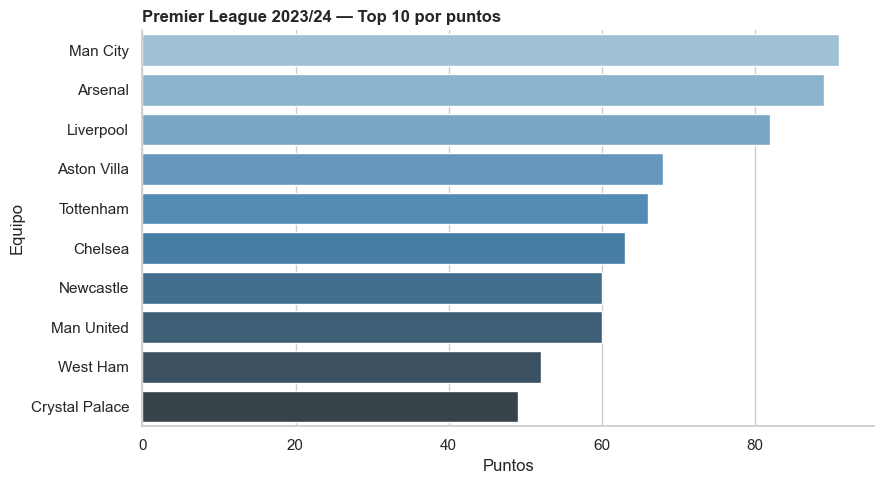

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=tabla_pos.head(10),   # solo el top 10
    x="Pts", y="Equipo",
    palette="Blues_d",
    ax=ax
)
ax.set_title("Premier League 2023/24 — Top 10 por puntos", loc="left", fontweight="bold")
ax.set_xlabel("Puntos")
sns.despine()
plt.tight_layout()
plt.show()

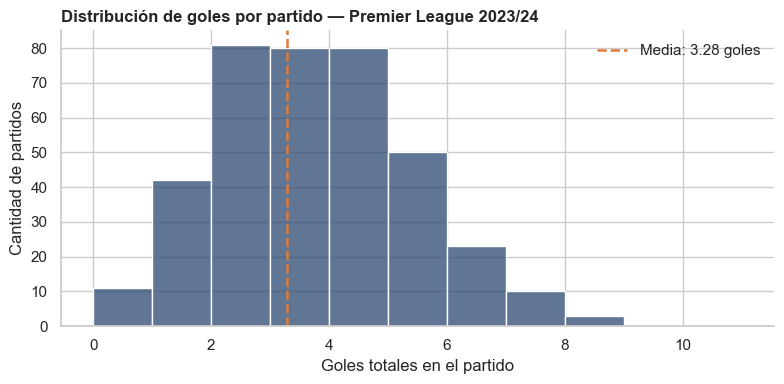

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    pl["goles_total"],
    bins=range(0, 12),     # barras de ancho 1 desde 0 hasta 11 goles
    kde=False,             # sin curva de densidad
    color="#2c4770", edgecolor="white",
    ax=ax
)
ax.axvline(
    pl["goles_total"].mean(),   # línea vertical en la media
    color="#e07b39", linewidth=1.8, linestyle="--",
    label=f'Media: {pl["goles_total"].mean():.2f} goles'
)
ax.set_title("Distribución de goles por partido — Premier League 2023/24",
             loc="left", fontweight="bold")
ax.set_xlabel("Goles totales en el partido")
ax.set_ylabel("Cantidad de partidos")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

---

## B6. Regresión lineal simple

¿Los tiros al arco explican cuántos goles mete un equipo en un partido?

Vamos a ajustar una regresión lineal simple: usamos `al_arco_local` como variable predictora y `goles_local` como variable a explicar.

$$\text{goles\_local} = \beta_0 + \beta_1 \cdot \text{al\_arco\_local} + \varepsilon$$

In [24]:
from sklearn.linear_model import LinearRegression

X_pl = pl[["al_arco_local"]].values   # predictor: tiros al arco (array 2D)
y_pl = pl["goles_local"].values       # variable a predecir: goles (array 1D)

modelo_pl = LinearRegression().fit(X_pl, y_pl)   # ajustar el modelo

print(f"β₀ = {modelo_pl.intercept_:.2f}   (goles esperados con 0 tiros al arco)")
print(f"β₁ = {modelo_pl.coef_[0]:.2f}   (cada tiro al arco adicional suma β₁ goles en promedio)")
print(f"R² = {modelo_pl.score(X_pl, y_pl):.3f}  (mucho mejor que Spotify — los tiros sí explican goles)")

β₀ = 0.28   (goles esperados con 0 tiros al arco)
β₁ = 0.28   (cada tiro al arco adicional suma β₁ goles en promedio)
R² = 0.347  (mucho mejor que Spotify — los tiros sí explican goles)


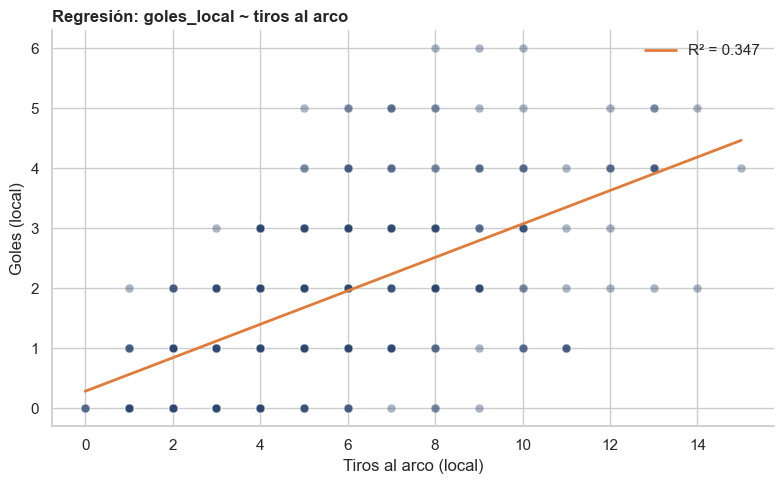

In [25]:
# 100 puntos equidistantes para dibujar la línea de regresión
x_rango_pl = np.linspace(X_pl.min(), X_pl.max(), 100).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(x=pl["al_arco_local"], y=pl["goles_local"],
                alpha=0.4, color="#2c4770", s=40, ax=ax)   # un punto por partido
ax.plot(x_rango_pl, modelo_pl.predict(x_rango_pl),         # línea de regresión ajustada
        color="#e07b39", linewidth=2,
        label=f"R² = {modelo_pl.score(X_pl, y_pl):.3f}")
ax.set_title("Regresión: goles_local ~ tiros al arco", loc="left", fontweight="bold")
ax.set_xlabel("Tiros al arco (local)")
ax.set_ylabel("Goles (local)")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

---

**Fuentes:**

Schwabish, J. A. (2014). An economist's guide to visualizing data. *Journal of Economic Perspectives*, 28(1), 209–234.

Thompson, J. (2020). *Spotify Songs* [Dataset]. TidyTuesday.

Football-Data.co.uk (2024). *Premier League 2023/24 Results* [Dataset].